# Classification Algorithms

**Goal**: Classify examples into distinct classes (categories).

We will use the breast cancer dataset (classify as malignant or benign). We will compare Logistic Regression, a Decision Tree, and a Random Forest (ensemble) on the same dataset.

### 1. Load the Dataset

Let's get the standard breast cancer dataset from sklearn.

In [1]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
print("Target classes:", data.target_names)

Target classes: ['malignant' 'benign']


### 2. Brief Exploration

Let's look at the first few rows using pandas.

In [2]:
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


Check how many examples we have for each class:

In [3]:
df['target'].value_counts()

target
1    357
0    212
Name: count, dtype: int64

### 3. Split into Features (X) and Target (y)

In [4]:
X = df.drop(columns=['target'])
y = df['target']

### 4. Train/Test Split

We split the data. We also use `stratify=y`, which ensures the train and test sets have the same ratio of classes as the original data.

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (455, 30)
Test size: (114, 30)


### 5. Baseline Model: Logistic Regression

Even though it has 'regression' in the name, Logistic Regression is used for classification.

In [6]:
from sklearn.linear_model import LogisticRegression
import warnings
warnings.filterwarnings('ignore') # Ignore convergence warnings for simplicity

model_log = LogisticRegression(max_iter=1000)
model_log.fit(X_train, y_train)

y_pred_log = model_log.predict(X_test)

Let's look at the accuracy and a Confusion Matrix.
A confusion matrix shows True Positives, False Positives, True Negatives, and False Negatives.

Logistic Regression Accuracy: 0.956140350877193


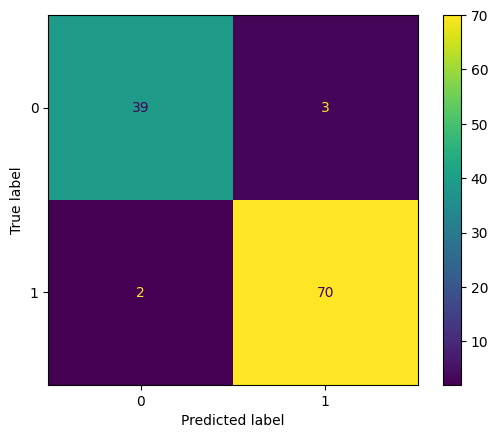

In [7]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

acc_log = accuracy_score(y_test, y_pred_log)
print("Logistic Regression Accuracy:", acc_log)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log)
plt.show()

### 6. Decision Tree

A decision tree splits data using a series of if/else rules. Limiting `max_depth` stops it from learning too many rules and overfitting.

In [8]:
from sklearn.tree import DecisionTreeClassifier

model_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
model_tree.fit(X_train, y_train)

y_pred_tree = model_tree.predict(X_test)

Evaluate the Decision Tree:

Decision Tree Accuracy: 0.9385964912280702


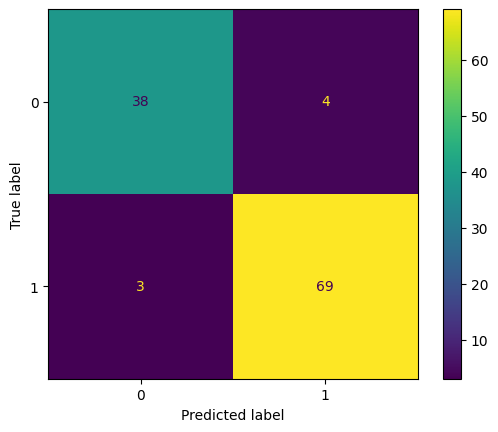

In [9]:
acc_tree = accuracy_score(y_test, y_pred_tree)
print("Decision Tree Accuracy:", acc_tree)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tree)
plt.show()

### 7. Ensemble Model: Random Forest

An 'ensemble' combines multiple models. A Random Forest combines many decision trees, letting them 'vote' on the final answer to get a more robust prediction.

In [10]:
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=50, random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)

Evaluate the Random Forest:

Random Forest Accuracy: 0.956140350877193


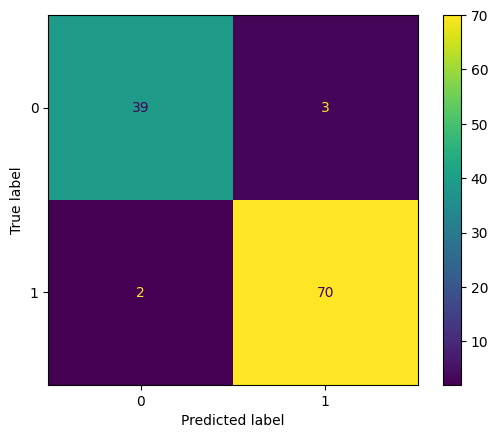

In [11]:
acc_rf = accuracy_score(y_test, y_pred_rf)
print("Random Forest Accuracy:", acc_rf)

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_rf)
plt.show()

### 8. Simple Comparison

Let's see how our 3 algorithms did on the exact same dataset.

*Note*: Logistic Regression and Random Forest often perform very well, but Decision Trees are much easier to interpret!

In [12]:
print("Logistic Regression:", acc_log)
print("Decision Tree:", acc_tree)
print("Random Forest:", acc_rf)

Logistic Regression: 0.956140350877193
Decision Tree: 0.9385964912280702
Random Forest: 0.956140350877193


### Try It Yourself!

**Exercises:**
1. In the Decision Tree cell, change `max_depth=3` to `max_depth=1` (a very shallow tree) or `max_depth=None` (no limit). How does accuracy change?
2. In the Random Forest cell, change `n_estimators=50` to `n_estimators=5` (only 5 trees). What happens to the performance?